In [2]:
import sys
sys.path.append('../src/')

from cryosim import atom
import matplotlib.pyplot as plt
import mrcfile
from cryosim import pdbtools
from cryosim import potential
import torch
from tqdm import tqdm
from cryosim.plotting_tools import plot3d, plot_slices
from cryosim.potential import PotentialBuilder

%load_ext autoreload
%autoreload 2

## Download PDB file

In [44]:
folder = '../pdb-data/'
filename = pdbtools.fetch_pdb_file("6e9d", output=folder)
filename

Assemblies available: 1
6e9d: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6e9d-assembly1.cif, skip fetching.


'../pdb-data/6e9d-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [45]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
assemble = True
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

Parsing ../pdb-data/6e9d-assembly1.cif.


Extracting atom coordinates and element: 0it [00:00, ?it/s]

(torch.Size([489900]), torch.Size([489900, 3]))

In [46]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'N', 'O', 'C', 'H', 'S'}


In [47]:
coords.shape

torch.Size([489900, 3])

In [48]:
# recenters coordinates onto origin (0,0,0)
center = pdbtools.center_of_particle(coords)
centered_coords = coords - center.reshape(1, -1)

## Convolution method

In [55]:
n = 512
dx = 0.788
vol_3d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_3d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

  0%|          | 0/5 [00:00<?, ?it/s]

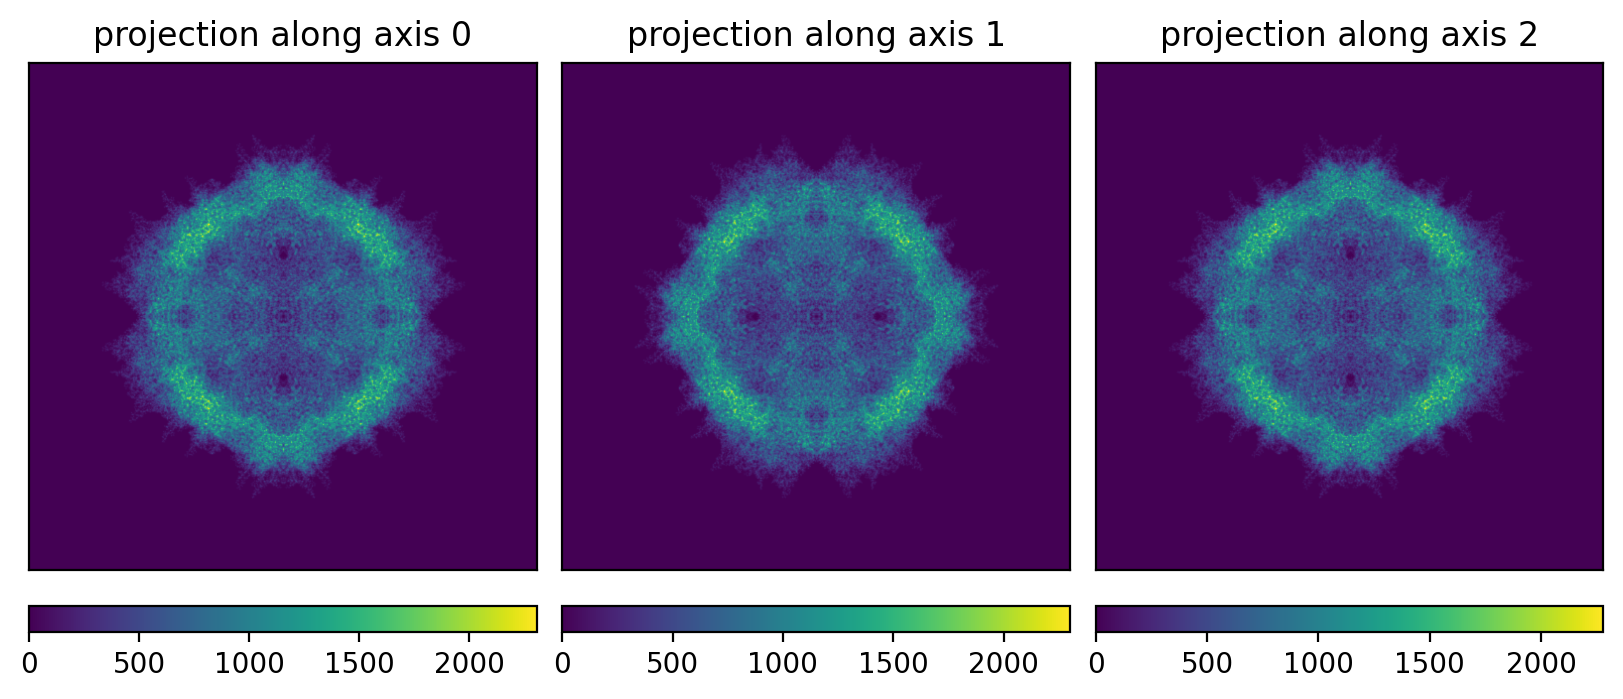

In [56]:
plot3d(vol_3d)

In [57]:
vol_2d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_2d(
    atomic_numbers,
    centered_coords,
    n,
    dx,
)

  0%|          | 0/5 [00:00<?, ?it/s]

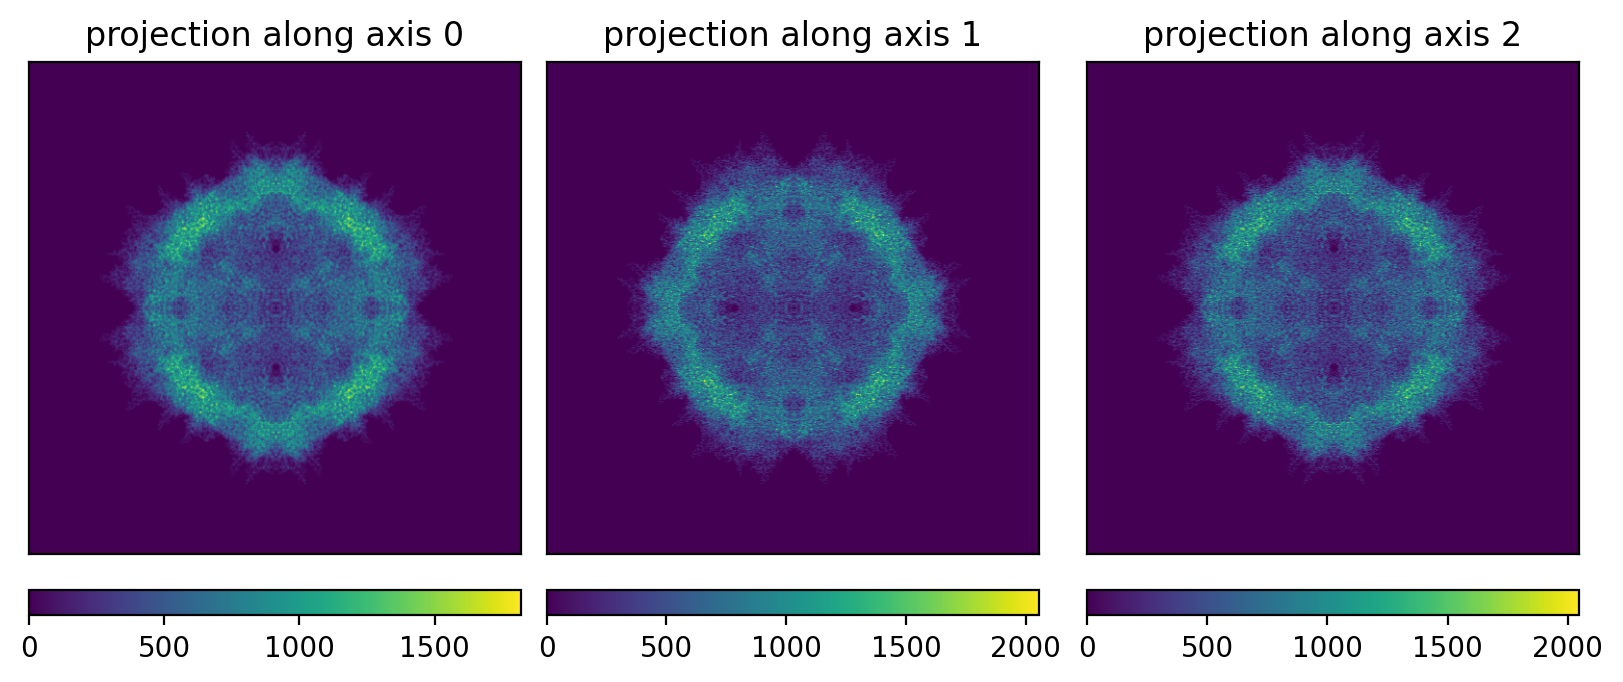

In [58]:
plot3d(vol_2d)

## Compare error between 2D and 3D

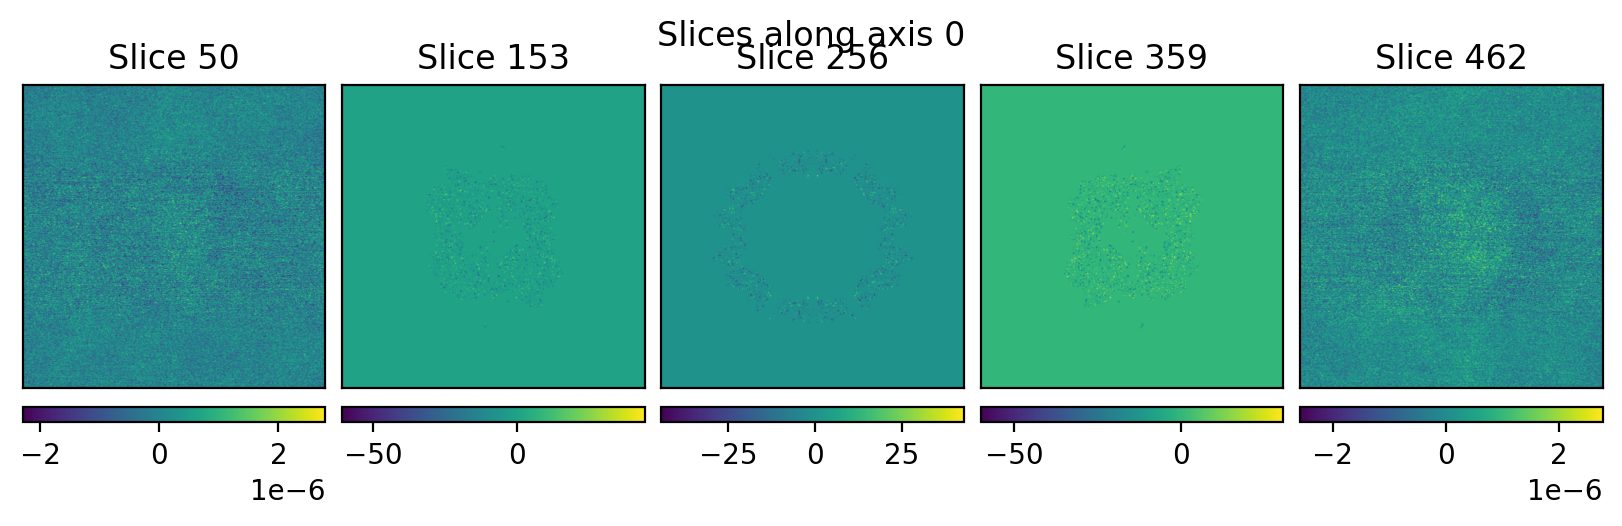

In [59]:
start_idx = 50
plot_slices(vol_2d - vol_3d, start_idx=start_idx, end_idx=n - start_idx)

## PotentialBuilder class

In [60]:
device = 'cuda'
pb = PotentialBuilder(n, dx, atomic_numbers, centered_coords).to(device)

In [61]:
with torch.no_grad():
    vol = pb()

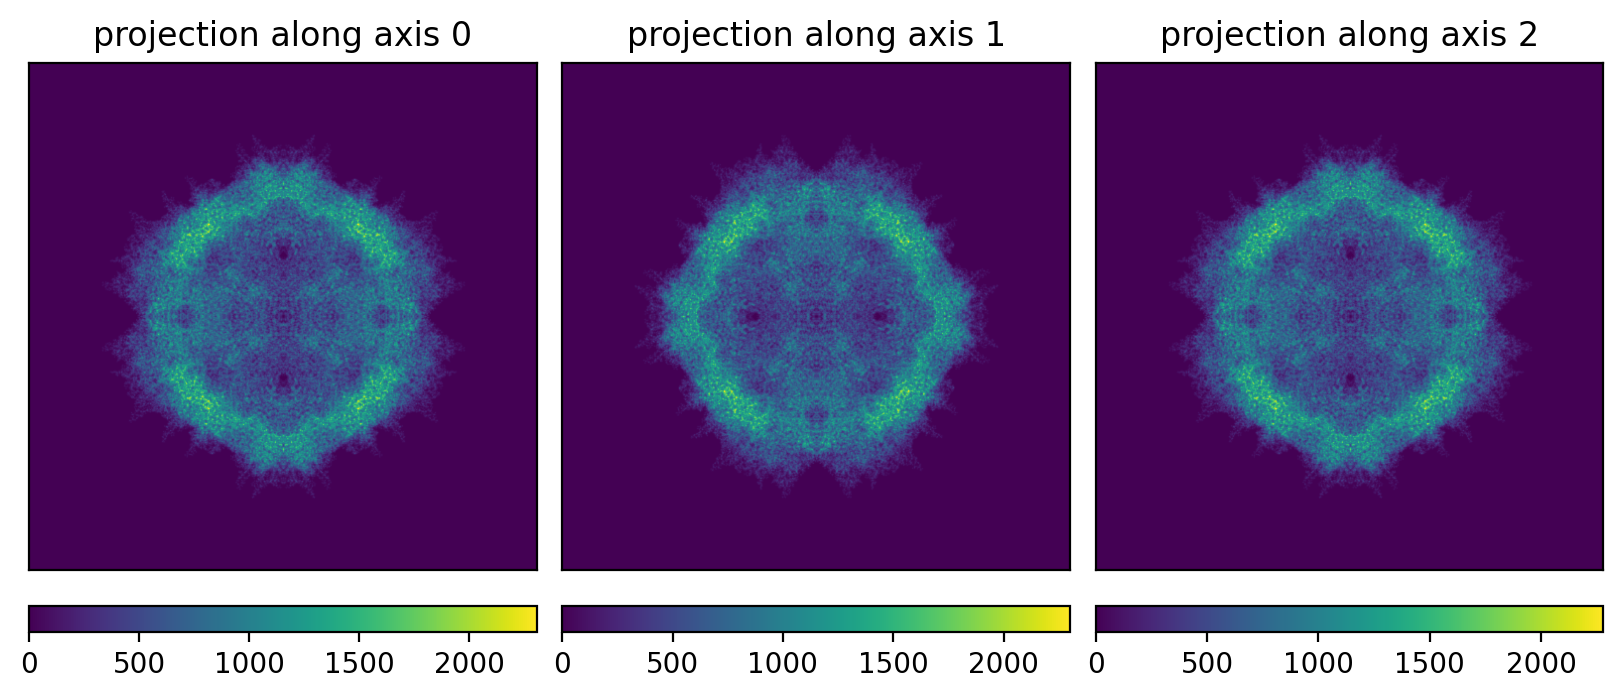

In [62]:
plot3d(vol.detach().cpu())

In [255]:
from cryosim.rotations import random_rotvec, rotate_volume, build_affine_matrix, rotate_coordinates, rotvec_to_rotation_matrix

In [259]:
quat = random_rotvec()
rm = rotvec_to_rotation_matrix(quat.unsqueeze(0))
am = build_affine_matrix(rm)

In [260]:
new_vol = rotate_volume(vol_3d, am)

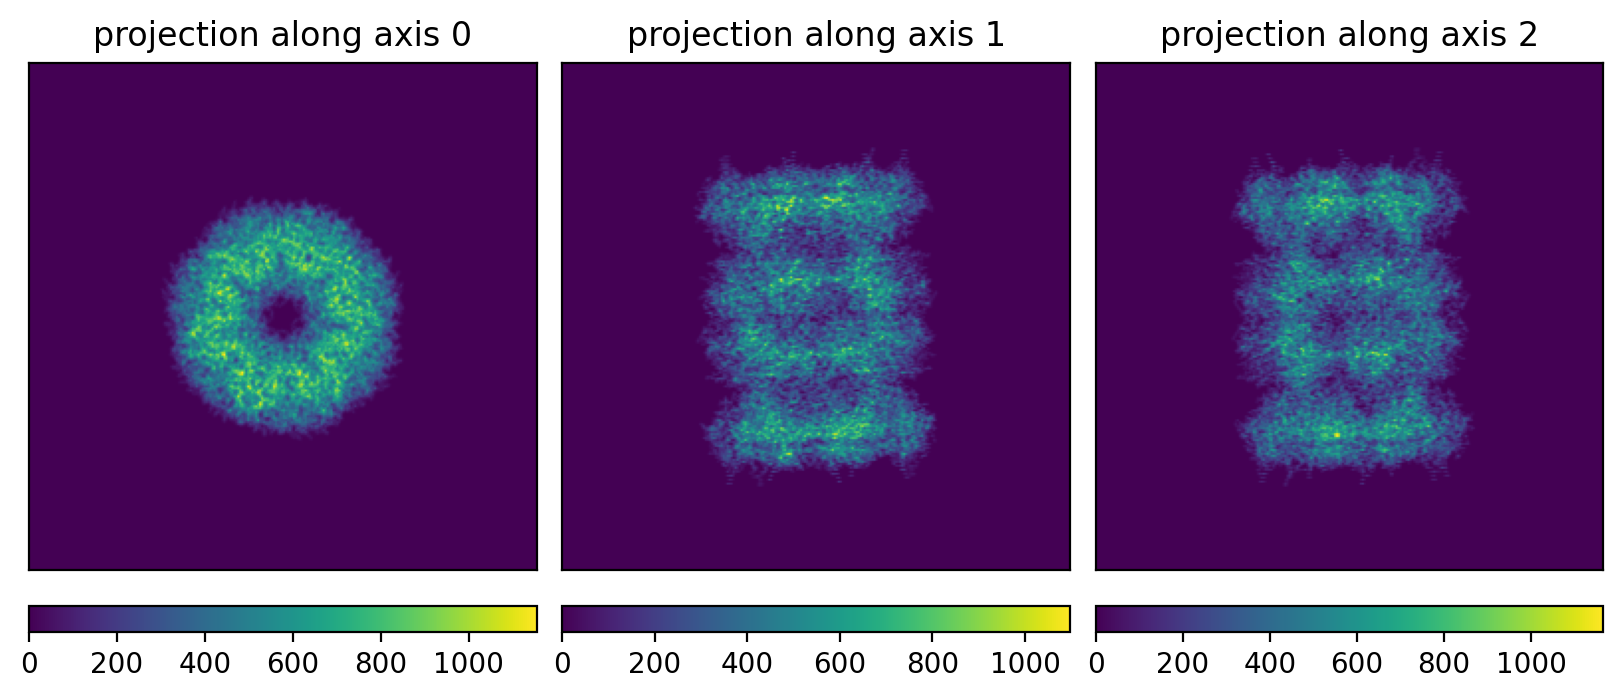

In [261]:
plot3d(new_vol.squeeze())

In [265]:
rot_coords = rotate_coordinates(centered_coords, quat, inverse=True)

In [266]:
n = 256
dx = 1
vol_2d, occupancy, atomic_potentials = potential.build_potential_volume_fftconvolve_2d(
    atomic_numbers,
    rot_coords,
    n,
    dx,
)

  0%|          | 0/4 [00:00<?, ?it/s]

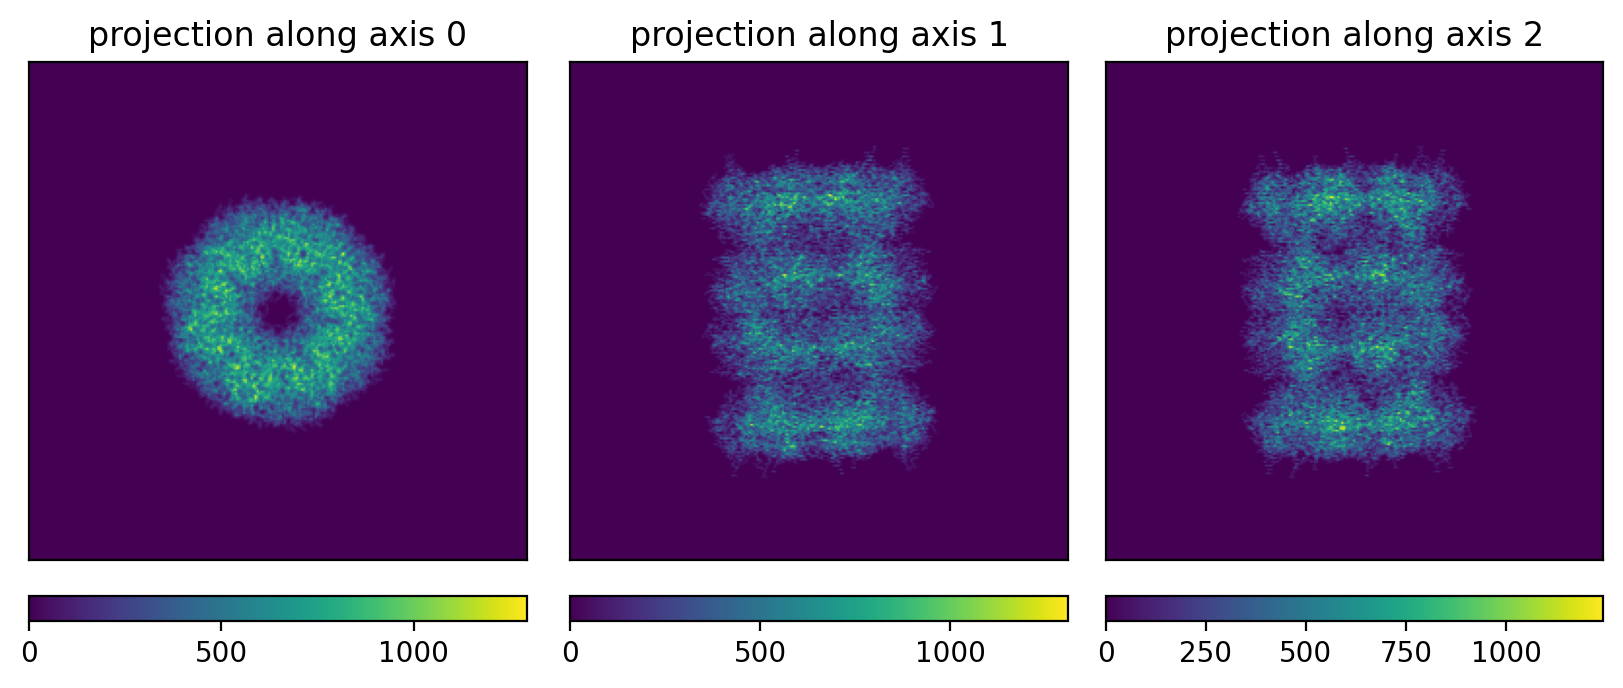

In [267]:
plot3d(vol_2d)